In [1]:
using ITensors, ITensorMPS, ProgressMeter, Plots, LinearAlgebra

include("main.jl")


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


run_mcmc_sweep (generic function with 1 method)

In [2]:
# Parameters to sweep
L_values = [16, 32, 64]
beta_values = vcat(
    range(0.3, stop=0.4, length=2),
    range(0.41, stop=0.48, length=4),
    range(0.5, stop=0.6, length=2)
)

D_bound = 2
N_samples = 2000 

# Dictionaries to store results
results_acc = Dict(L => Float64[] for L in L_values)
results_e = Dict(L => Float64[] for L in L_values)

Dict{Int64, Vector{Float64}} with 3 entries:
  32 => []
  64 => []
  16 => []

In [3]:
println("Starting Phase Transition Sweep for D_bound=$D_bound")
println("Betas: ", beta_values)

for L in L_values
    println("\n--- Running for Grid $(L)x$(L) ---")
    
    @showprogress "L=$L Sweep: " for beta in beta_values
        acc, e = run_mcmc_sweep(L, L, beta, D_bound, N_samples)
        push!(results_acc[L], acc)
        push!(results_e[L], e)
    end
end

Starting Phase Transition Sweep for D_bound=2
Betas: [0.3, 0.4, 0.41, 0.43333333333333335, 0.45666666666666667, 0.48, 0.5, 0.6]

--- Running for Grid 16x16 ---


L=16 Sweep: 100%|███████████████████████████████████████| Time: 0:35:06



--- Running for Grid 32x32 ---


L=32 Sweep: 100%|███████████████████████████████████████| Time: 2:29:24



--- Running for Grid 64x64 ---


L=64 Sweep: 100%|███████████████████████████████████████| Time: 10:58:04


In [13]:
using JLD2

output_file = "ising_mcmc_results_D$(D_bound).jld2"

jldsave(output_file; 
    results_acc = results_acc,
    results_e = results_e,
    beta_values = beta_values,
    L_values = L_values,
    D_bound = D_bound,
    N_samples = N_samples
)

In [15]:
pwd()

"/home/jmarquezol/.local/share/Trash/files/jl/icfo_intern"

In [10]:
using JLD2

filename = "ising_mcmc_results_D2.jld2"

@load filename results_acc results_e beta_values L_values D_bound N_samples

6-element Vector{Symbol}:
 :results_acc
 :results_e
 :beta_values
 :L_values
 :D_bound
 :N_samples

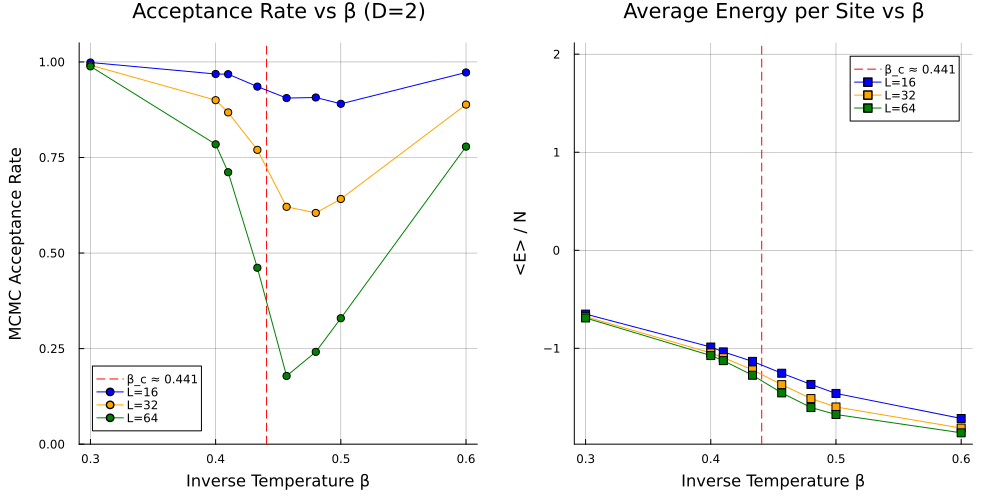

In [7]:
# PLOTTING
beta_c_analytical = log(1 + sqrt(2)) / 2  # ~ 0.44068

p1 = plot(title="Acceptance Rate vs β (D=$D_bound)", xlabel="Inverse Temperature β", ylabel="MCMC Acceptance Rate", ylims=(0, 1.05), grid=true, gridalpha=0.4, legend=:bottomleft)
p2 = plot(title="Average Energy per Site vs β", xlabel="Inverse Temperature β", ylabel="<E> / N", grid=true, gridalpha=0.4, legend=:topright)

# Analytical critical lines
vline!(p1, [beta_c_analytical], color=:red, linestyle=:dash, label="β_c ≈ 0.441")
vline!(p2, [beta_c_analytical], color=:red, linestyle=:dash, label="β_c ≈ 0.441")

colors = [:blue, :orange, :green]

# Plot the data
for (idx, L) in enumerate(L_values)
    plot!(p1, beta_values, results_acc[L], marker=:circle, color=colors[idx], label="L=$L")
    plot!(p2, beta_values, results_e[L], marker=:square, color=colors[idx], label="L=$L")
end

# Combine layouts side-by-side
plot(p1, p2, layout=(1, 2), size=(1000, 500), margin=5Plots.mm)

---

In [8]:
function run_toy_model_error_tracker(Lx::Int, beta::Float64, D_bound::Int)
    Ly = 8 # FIXED TO 8: This is the magic number for the toy model
    
    A, s_inds, v_inds = create_ising_peps(Lx, Ly, beta, 1.0)
    b = [Index(2, "Site,b=$y") for y in 1:Ly]
    
    # 1. INITIALIZATION: Create the exact and truncated bottom environments
    tensors_Lx = ITensor[]
    for y in 1:Ly
        T_traced = A[Lx, y] * ITensor([1.0, 1.0], s_inds[Lx, y])
        T_traced = replaceinds(T_traced, [v_inds[Lx-1, y]] => [b[y]])
        push!(tensors_Lx, T_traced)
    end
    
    # Both start as the exact same bottom row
    E_exact = MPS(tensors_Lx)
    E_trunc = MPS(tensors_Lx)
    
    # We MUST track the log normalizations, otherwise probabilities lose meaning
    log_Z_exact = 0.0
    log_Z_trunc = 0.0
    
    # Arrays to store the data your supervisor wants to see
    x_values = Int[]
    fidelities = Float64[]
    worst_case_ratios = Float64[]
    
    # 2. THE SWEEP: Move upwards row by row
    for x in Lx-1:-1:2
        # Build the MPO for the current row
        tensors_mpo = ITensor[]
        for y in 1:Ly
            T_traced = A[x, y] * ITensor([1.0, 1.0], s_inds[x, y])
            T_traced = replaceinds(T_traced, [v_inds[x, y], v_inds[x-1, y]] => [b[y], b[y]'])
            push!(tensors_mpo, T_traced)
        end
        MPO_x = MPO(tensors_mpo)
        
        # --- THE SPLIT REALITY ---
                
        # A. The Exact Universe
        E_exact = apply(MPO_x, E_exact; maxdim=16, cutoff=1e-15)
        E_exact = noprime(E_exact)
        
        # Sweep right-to-left to bound tensors 2-8, pushing magnitude to tensor 1
        orthogonalize!(E_exact, 1) 
        n_exact = norm(E_exact[1])
        E_exact[1] ./= n_exact
        log_Z_exact += log(n_exact)
        
        # B. The Truncated Universe
        E_trunc = apply(MPO_x, E_trunc; maxdim=D_bound, cutoff=1e-10)
        E_trunc = noprime(E_trunc)
        
        # Sweep right-to-left to bound tensors 2-8, pushing magnitude to tensor 1
        orthogonalize!(E_trunc, 1)
        n_trunc = norm(E_trunc[1])
        E_trunc[1] ./= n_trunc
        log_Z_trunc += log(n_trunc)
        
        # 3. MEASURE ADDITIVE ERROR (Fidelity)
        # How far apart are the two environments as vectors?
        fidelity = abs(inner(E_exact, E_trunc))
        push!(fidelities, fidelity)
        
        # 4. MEASURE MULTIPLICATIVE ERROR (The Mengersen-Tweedie Bound)
        max_ratio_at_x = 0.0
        
        # Exhaustive loop over all 2^8 = 256 physical spin configurations
        for i in 0:255
            # Convert integer to binary spin array (0=Up, 1=Dn)
            spins = [(i >> (j - 1)) & 1 for j in 1:Ly]
            
            row_tensors_exact = ITensor[]
            row_tensors_trunc = ITensor[]
            
            for y in 1:Ly
                T = A[x-1, y]
                
                # 1. Project the physical spin configuration onto the tensor
                state_vec = spins[y] == 0 ? [1.0, 0.0] : [0.0, 1.0]
                T *= ITensor(state_vec, s_inds[x-1, y])
                
                # 2. Trace out the upward vertical bond (if we are not at the absolute top row)
                if (x - 1) > 1
                    T *= ITensor([1.0, 1.0], v_inds[x-2, y])
                end
                
                # 3. Contract with the respective bottom environments
                T_exact = T * replaceinds(E_exact[y], b[y] => v_inds[x-1, y])
                T_trunc = T * replaceinds(E_trunc[y], b[y] => v_inds[x-1, y])
                
                push!(row_tensors_exact, T_exact)
                push!(row_tensors_trunc, T_trunc)
            end
            
            # Multiply the 8 tensors together to collapse the horizontal bonds and extract the scalar probability
            prob_exact = abs(scalar(reduce(*, row_tensors_exact)))
            prob_trunc = abs(scalar(reduce(*, row_tensors_trunc)))
            
            # Guard against log(0) domain errors just in case truncation is aggressive
            if prob_trunc > 1e-30 && prob_exact > 1e-30
                # Calculate absolute probabilities in log space
                log_prob_exact = log(prob_exact) + log_Z_exact
                log_prob_trunc = log(prob_trunc) + log_Z_trunc
                
                # Calculate the ratio: Pi_exact(x) / Pi_approx(x)
                current_ratio = exp(log_prob_exact - log_prob_trunc)
                
                # Keep the worst-case scenario
                if current_ratio > max_ratio_at_x
                    max_ratio_at_x = current_ratio
                end
            end
        end # <--- END OF THE 256 CONFIGURATION LOOP
        
        # ---> ADD THESE TWO LINES TO SAVE THE DATA <---
        push!(x_values, Lx - x + 1) # Distance from the bottom (how many rows we have applied)
        push!(worst_case_ratios, max_ratio_at_x)
        
    end # <--- END OF THE ROW SWEEP LOOP
    
    return x_values, fidelities, worst_case_ratios
end

run_toy_model_error_tracker (generic function with 1 method)

Running Toy Model at High Temperature (T = 3.5)...
Running Toy Model at Critical Temperature (T = 2.269)...
Simulations complete. Generating plots...


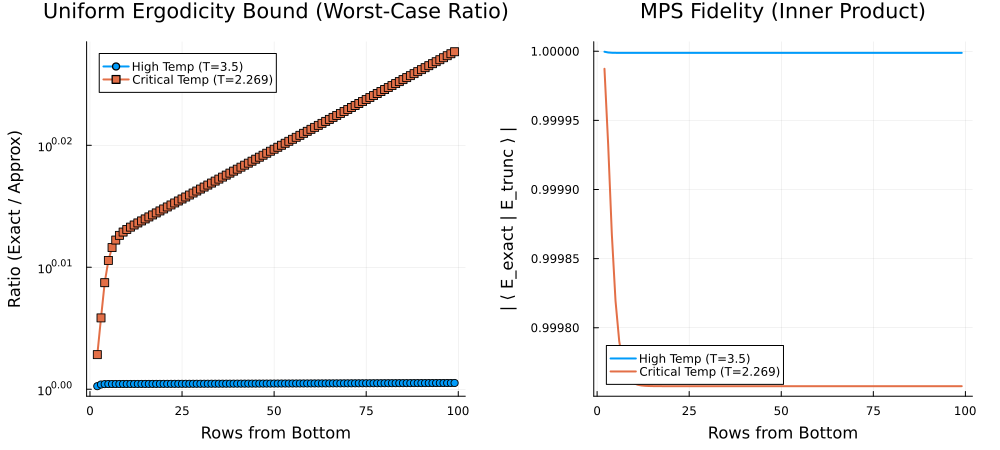

In [10]:
# Execute the Toy Model and Plot the Mengersen-Tweedie Bound

# 1. Set Simulation Parameters
Lx = 100           # Length of the strip
D_bound = 2       # Your TNMH truncation bond dimension

# High Temperature (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temperature (Diverging Correlation Length)
T_crit = 2.269
beta_crit = 1.0 / T_crit

# 2. Run the Simulations
println("Running Toy Model at High Temperature (T = $T_high)...")
x_vals_high, fid_high, ratios_high = run_toy_model_error_tracker(Lx, beta_high, D_bound)

println("Running Toy Model at Critical Temperature (T = $T_crit)...")
x_vals_crit, fid_crit, ratios_crit = run_toy_model_error_tracker(Lx, beta_crit, D_bound)

# 3. Plotting the Results
println("Simulations complete. Generating plots...")

# Plot A: The Mengersen-Tweedie Worst-Case Ratio (The "C" Constant)
# We use a log10 scale for the Y-axis because the error ratio can grow exponentially
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", 
          xlabel="Rows from Bottom", 
          ylabel="Ratio (Exact / Approx)", 
          yscale=:log10, 
          legend=:topleft, 
          grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Plot B: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", 
          xlabel="Rows from Bottom", 
          ylabel="| ⟨ E_exact | E_trunc ⟩ |", 
          legend=:bottomleft, 
          grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

# Combine into a single figure side-by-side
plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

Running Toy Model at High Temperature (T = 3.5)...
Running Toy Model at Critical Temperature (T = 2.269)...
Simulations complete. Generating plots...


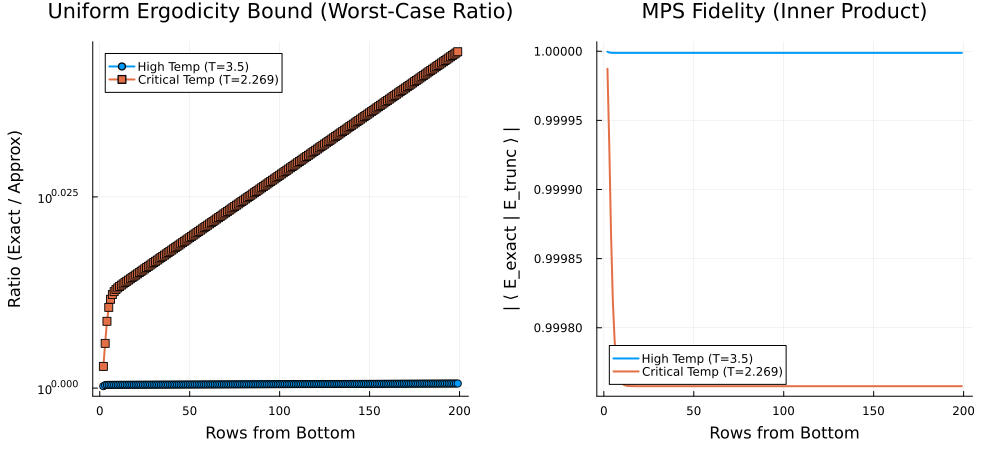

In [13]:
# Execute the Toy Model and Plot the Mengersen-Tweedie Bound

# 1. Set Simulation Parameters
Lx = 200           # Length of the strip
D_bound = 2       # Your TNMH truncation bond dimension

# High Temperature (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temperature (Diverging Correlation Length)
T_crit = 2.269
beta_crit = 1.0 / T_crit

# 2. Run the Simulations
println("Running Toy Model at High Temperature (T = $T_high)...")
x_vals_high, fid_high, ratios_high = run_toy_model_error_tracker(Lx, beta_high, D_bound)

println("Running Toy Model at Critical Temperature (T = $T_crit)...")
x_vals_crit, fid_crit, ratios_crit = run_toy_model_error_tracker(Lx, beta_crit, D_bound)

# 3. Plotting the Results
println("Simulations complete. Generating plots...")

# Plot A: The Mengersen-Tweedie Worst-Case Ratio (The "C" Constant)
# We use a log10 scale for the Y-axis because the error ratio can grow exponentially
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", 
          xlabel="Rows from Bottom", 
          ylabel="Ratio (Exact / Approx)", 
          yscale=:log10, 
          legend=:topleft, 
          grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Plot B: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", 
          xlabel="Rows from Bottom", 
          ylabel="| ⟨ E_exact | E_trunc ⟩ |", 
          legend=:bottomleft, 
          grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

# Combine into a single figure side-by-side
plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

Running Toy Model at High Temperature (T = 3.5)...
Running Toy Model at Critical Temperature (T = 2.269)...
Simulations complete. Generating plots...


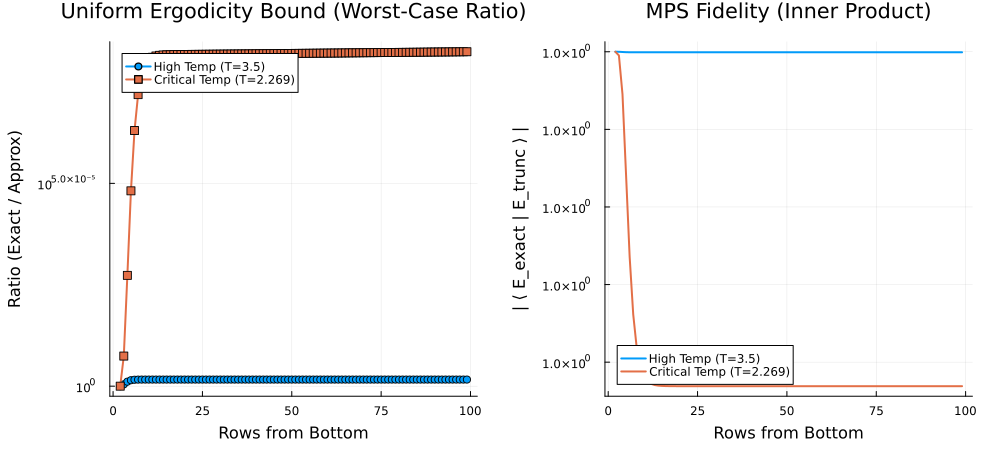

In [11]:
# Execute the Toy Model and Plot the Mengersen-Tweedie Bound

# 1. Set Simulation Parameters
Lx = 100           # Length of the strip
D_bound = 4       # Your TNMH truncation bond dimension

# High Temperature (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temperature (Diverging Correlation Length)
T_crit = 2.269
beta_crit = 1.0 / T_crit

# 2. Run the Simulations
println("Running Toy Model at High Temperature (T = $T_high)...")
x_vals_high, fid_high, ratios_high = run_toy_model_error_tracker(Lx, beta_high, D_bound)

println("Running Toy Model at Critical Temperature (T = $T_crit)...")
x_vals_crit, fid_crit, ratios_crit = run_toy_model_error_tracker(Lx, beta_crit, D_bound)

# 3. Plotting the Results
println("Simulations complete. Generating plots...")

# Plot A: The Mengersen-Tweedie Worst-Case Ratio (The "C" Constant)
# We use a log10 scale for the Y-axis because the error ratio can grow exponentially
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", 
          xlabel="Rows from Bottom", 
          ylabel="Ratio (Exact / Approx)", 
          yscale=:log10, 
          legend=:topleft, 
          grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Plot B: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", 
          xlabel="Rows from Bottom", 
          ylabel="| ⟨ E_exact | E_trunc ⟩ |", 
          legend=:bottomleft, 
          grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

# Combine into a single figure side-by-side
plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

Running Toy Model at High Temperature (T = 3.5)...
Running Toy Model at Critical Temperature (T = 2.269)...
Simulations complete. Generating plots...


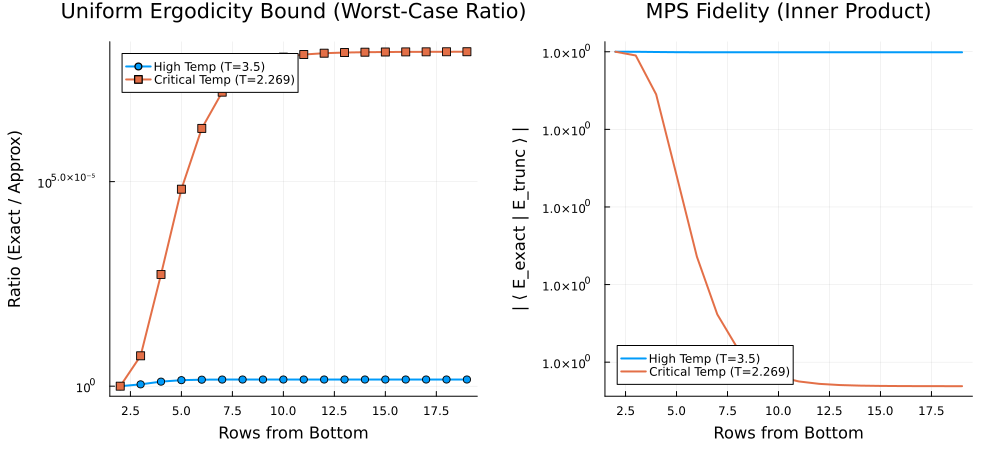

In [12]:
# Execute the Toy Model and Plot the Mengersen-Tweedie Bound

# 1. Set Simulation Parameters
Lx = 20           # Length of the strip
D_bound = 4       # Your TNMH truncation bond dimension

# High Temperature (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temperature (Diverging Correlation Length)
T_crit = 2.269
beta_crit = 1.0 / T_crit

# 2. Run the Simulations
println("Running Toy Model at High Temperature (T = $T_high)...")
x_vals_high, fid_high, ratios_high = run_toy_model_error_tracker(Lx, beta_high, D_bound)

println("Running Toy Model at Critical Temperature (T = $T_crit)...")
x_vals_crit, fid_crit, ratios_crit = run_toy_model_error_tracker(Lx, beta_crit, D_bound)

# 3. Plotting the Results
println("Simulations complete. Generating plots...")

# Plot A: The Mengersen-Tweedie Worst-Case Ratio (The "C" Constant)
# We use a log10 scale for the Y-axis because the error ratio can grow exponentially
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", 
          xlabel="Rows from Bottom", 
          ylabel="Ratio (Exact / Approx)", 
          yscale=:log10, 
          legend=:topleft, 
          grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Plot B: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", 
          xlabel="Rows from Bottom", 
          ylabel="| ⟨ E_exact | E_trunc ⟩ |", 
          legend=:bottomleft, 
          grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

# Combine into a single figure side-by-side
plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)